In [1]:
print("Hello12234")

Hello12234


                    DAY -8

🐍 Python for Network Engineers — Day 8: List Comprehensions
Part 1 — The concept & why it matters
A list comprehension is a compact, one-line way to build a new list from an existing one. It rolls the "create an empty list → for loop → append" pattern (remember Day 2?) into a single readable expression.
The shape is: [ expression for item in iterable if condition ] — read it as "give me expression for every item in the collection, but only if condition is true." The if part is optional.
Why it matters for network engineering: our daily work is full of "take this list and transform/filter it" — pull every down interface from a status list, strip whitespace off lines of show output, build a list of management IPs from an inventory, or grab only the VLANs above 100. Comprehensions make that crisp and far easier to read than a multi-line loop. You'll see them everywhere in real automation code, so recognizing and writing them is a genuine intermediate milestone.
Part 2 — Example code
① The basic transform — build one list from another:
octets = ["10", "0", "0", "1"]
# turn each string into an int
numbers = [int(o) for o in octets]
print(numbers)            # [10, 0, 0, 1]
# build interface config names
ports = [1, 2, 3]
intf = [f"GigabitEthernet0/{p}" for p in ports]
print(intf)               # ['GigabitEthernet0/1', 'GigabitEthernet0/2', 'GigabitEthernet0/3']
② Add an if to filter — keep only what matches:
interfaces = {
    "Gi0/1": "up",
    "Gi0/2": "down",
    "Gi0/3": "up",
    "Gi0/4": "down",
}
# only the interfaces that are DOWN (compare to the Day 3 loop — same result, one line!)
down = [name for name, state in interfaces.items() if state == "down"]
print(down)               # ['Gi0/2', 'Gi0/4']
③ A real-world favorite — clean up messy CLI output:
raw = ["  10.1.1.1  ", "", "10.1.1.2", "   ", "10.1.1.3 "]
# strip whitespace AND drop the blank lines in one shot
clean = [line.strip() for line in raw if line.strip()]
print(clean)              # ['10.1.1.1', '10.1.1.2', '10.1.1.3']
That third example is the pattern you'll reach for constantly when parsing the output of show commands.
Part 3 — Practice question
You're given a list of VLAN IDs pulled from a switch:
vlans = [1, 10, 20, 105, 200, 4094, 50]
👉 Using a single list comprehension, build a new list called user_vlans that contains only the VLANs greater than 100. Expected result: [105, 200, 4094].
Bonus: write a second comprehension that produces the names for those VLANs as strings like "VLAN105", "VLAN200", "VLAN4094" (hint: combine an f-string with the if filter).
Reply with your solution and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes


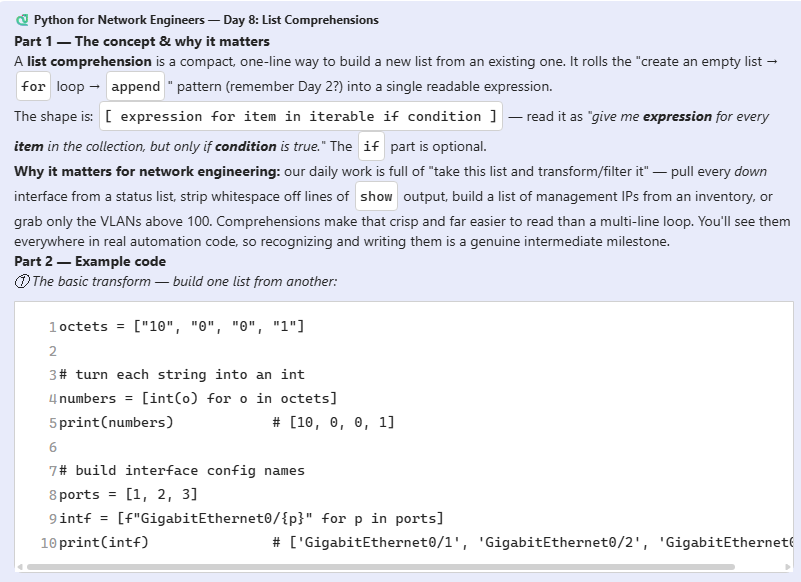

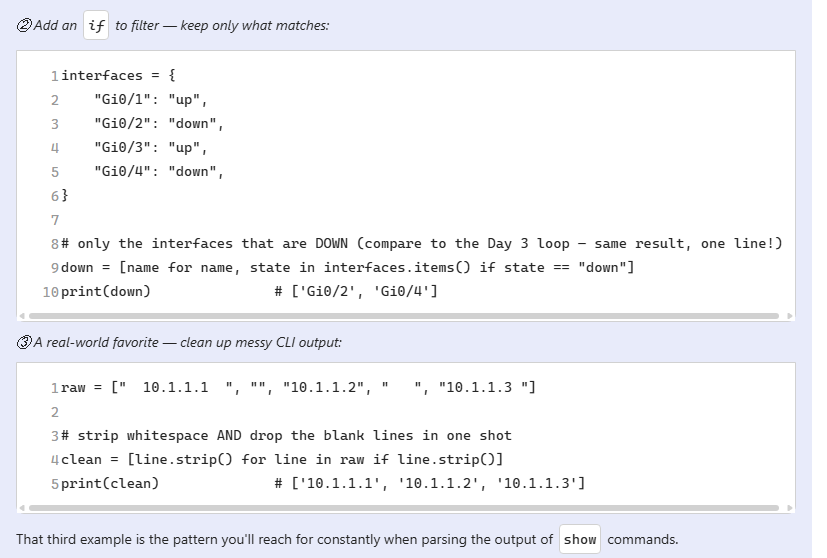

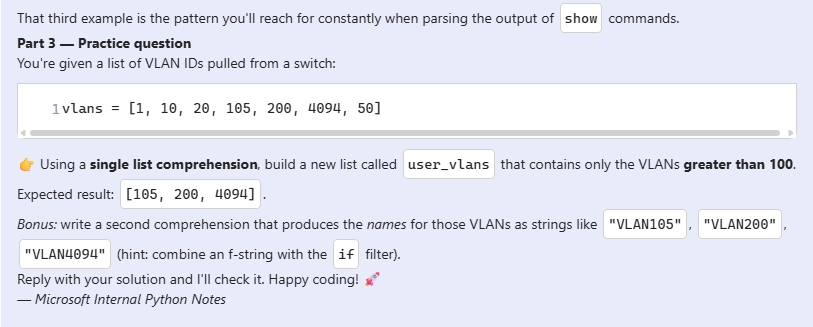

In [2]:
octets = ["10", "0", "0", "1"]

#turn each string into an int

numbers = [int(o) for o in octets]

print(numbers)

[10, 0, 0, 1]


In [6]:
octets = ["10", "0", "0", "1", "-1"]

#turn each string into an int

numbers = [int(o) for o in octets]

print(numbers)

[10, 0, 0, 1, -1]


In [5]:
octets = ["10", "0", "0", "1", "-1", "0.004"]

#turn each string into an int

numbers = [int(o) for o in octets]

print(numbers)

ValueError: invalid literal for int() with base 10: '0.004'

In [7]:
#build interface config names 

ports = [1, 2, 3]

intf = [f"GigabitEthernet0/{p}" for p in ports]
print(intf)

['GigabitEthernet0/1', 'GigabitEthernet0/2', 'GigabitEthernet0/3']


In [10]:
port = [1, 10, 30, 45, 443, 80, 22, 23, 53, 25, 69, 68, 161, 162]

intef = [f"portnumbers are{q}" for q in port]
print(intef)

['portnumbers are1', 'portnumbers are10', 'portnumbers are30', 'portnumbers are45', 'portnumbers are443', 'portnumbers are80', 'portnumbers are22', 'portnumbers are23', 'portnumbers are53', 'portnumbers are25', 'portnumbers are69', 'portnumbers are68', 'portnumbers are161', 'portnumbers are162']


In [13]:
port = [1, 10, 30, 45, 443, 80, 22, 23, 53, 25, 69, 68, 161, 162]

intef = [f"portnumbers are{q}" for q in port]
print("\n".join(intef))

portnumbers are1
portnumbers are10
portnumbers are30
portnumbers are45
portnumbers are443
portnumbers are80
portnumbers are22
portnumbers are23
portnumbers are53
portnumbers are25
portnumbers are69
portnumbers are68
portnumbers are161
portnumbers are162


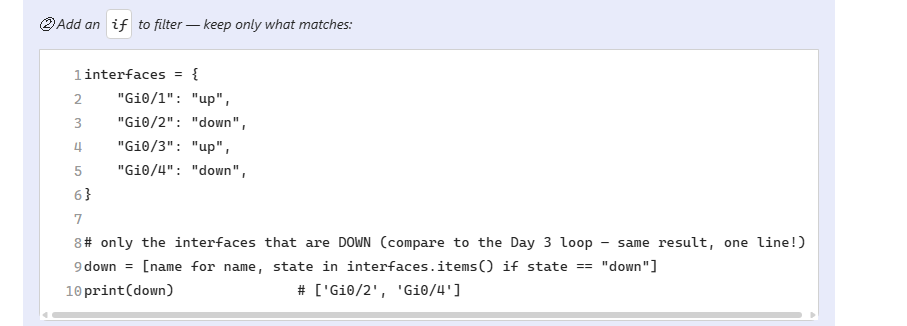

In [15]:
interfaces = {
    "Gi0/1" : "up",
    "Gi0/2" : "down",
    "Gi0/3" : "up",
    "Gi0/4" : "down"
}

#only the interfaces that are DOWN 

down = [name for name, state in interfaces.items() if state == "down"]
print(down)

['Gi0/2', 'Gi0/4']


In [17]:
down = []

for name, state in interfaces.items():
    if state == "down":
        down.append(name)

print(down)


['Gi0/2', 'Gi0/4']


In [18]:
interfaces = {
    "Gi0/1" : "up",
    "Gi0/2" : "down",
    "Gi0/3" : "up",
    "Gi0/4" : "down"
}

down_msgs = [
    f"{name} is DOWN - check cable"
    for name, state in interfaces.items()
    if state == "down"
]

print("\n".join(down_msgs))

Gi0/2 is DOWN - check cable
Gi0/4 is DOWN - check cable


In [19]:
reason = {
    "Gi0/2": "No carrier",
    "Gi0/4": "Admin shutdown"
}

for name, state in interfaces.items():
    if state == "down":
        print(f"{name} is DOWN - {reason.get(name, 'Unknown issue')}")

Gi0/2 is DOWN - No carrier
Gi0/4 is DOWN - Admin shutdown


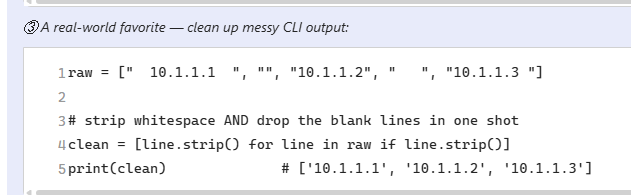

In [20]:
raw = ["    10.1.1.1    ", "", "10.1.1.2", " ", "10.1.1.3   "]

#strip whitespace AND drop the blank lines in one shot
clean = [line.strip() for line in raw if line.strip()]
print(clean)

['10.1.1.1', '10.1.1.2', '10.1.1.3']


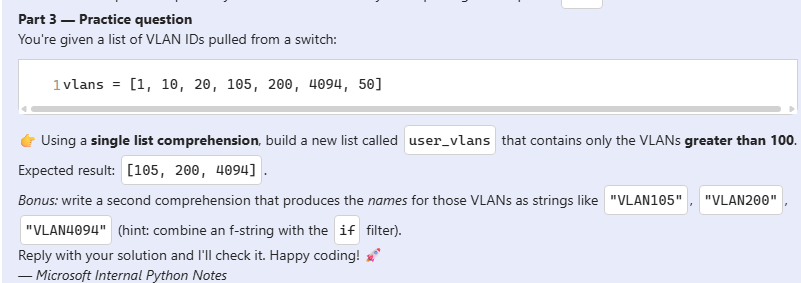

In [23]:
vlans = [1, 10, 20, 105, 200, 4094, 50]

user_vlans = []

for vlan in vlans:
    if vlan >= 100:
        print(vlan)

105
200
4094


In [24]:
vlans = [1, 10, 20, 105, 200, 4094, 50]

user_vlans = [vlan for vlan in vlans if vlan > 100]

print(user_vlans)


[105, 200, 4094]


In [25]:
vlan_names = [f"VLAN{vlan}" for vlan in vlans if vlan > 100]

print(vlan_names)


['VLAN105', 'VLAN200', 'VLAN4094']


In [1]:
print("hello")

hello


🐍 Python for Network Engineers — Day 9: Regular Expressions (the re module)
Part 1 — The concept & why it matters
A regular expression (regex) is a tiny pattern language for finding and extracting text. Instead of hand-slicing strings, you describe the shape of what you want — "an IP address", "an interface name", "a number after the word packets" — and let re pull it out.
Why it matters for network engineering: our job is drowning in semi-structured text — show ip interface brief, show version, syslog lines, BGP neighbor tables. APIs give clean JSON, but the CLI gives walls of text. Regex is how you reliably scrape the one value you need (an uptime, a serial number, a neighbor IP) out of that output. It's the bridge between "raw show output" and "data your script can act on."
The handful of pieces you'll use 90% of the time:
\d = a digit, \d+ = one or more digits
\w = a word character (letter/digit/underscore), \s = whitespace
. = any character, + = one-or-more, * = zero-or-more
( ... ) = a capture group — the part you want to extract
Always write patterns as raw strings: r"..." so backslashes behave
Three workhorse functions: re.search() (find the first match), re.findall() (get every match as a list), and re.sub() (find-and-replace).
Part 2 — Example code
① re.search + a capture group — pull one value out of a line:
Plain Text
import re
line = "GigabitEthernet0/1 is up, line protocol is up"
# capture the interface name at the start of the line
m = re.search(r"^(\S+) is (\w+)", line)
if m:
    print(m.group(1))   # GigabitEthernet0/1   (first group)
    print(m.group(2))   # up                   (second group)

② re.findall — grab every IP address in a blob of output:
Plain Text
output = """
  10.0.0.1        YES manual up
  10.0.0.254      YES manual up
  192.168.1.1     YES DHCP   down
"""
ips = re.findall(r"\d+\.\d+\.\d+\.\d+", output)
print(ips)   # ['10.0.0.1', '10.0.0.254', '192.168.1.1']

③ Multiple capture groups — turn a status line into structured data:
Plain Text
brief = "Gi0/1  10.0.0.1  up  up"
m = re.search(r"(\S+)\s+(\d+\.\d+\.\d+\.\d+)\s+(\w+)\s+(\w+)", brief)
if m:
    intf, ip, admin, proto = m.groups()
    print(f"{intf} -> {ip} (admin={admin}, proto={proto})")
    # Gi0/1 -> 10.0.0.1 (admin=up, proto=up)

④ re.sub — scrub/replace (e.g. mask the last octet for a report):
Plain Text
text = "host 10.0.0.42 reachable"
masked = re.sub(r"(\d+\.\d+\.\d+)\.\d+", r"\1.x", text)
print(masked)   # host 10.0.0.x reachable

Part 3 — Practice question
You've captured this line from show version:
Plain Text
line = "System uptime is 14 days, 3 hours, 22 minutes"
👉 Using a single re.search with three capture groups, extract the days, hours, and minutes as separate values, then print: Up for 14d 3h 22m.
Bonus: given a list of syslog lines, use re.findall(r"\d+\.\d+\.\d+\.\d+", ...) to collect every source IP, then wrap it in set(...) (remember Day 4!) to get the unique offenders.
Reply with your solution and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes

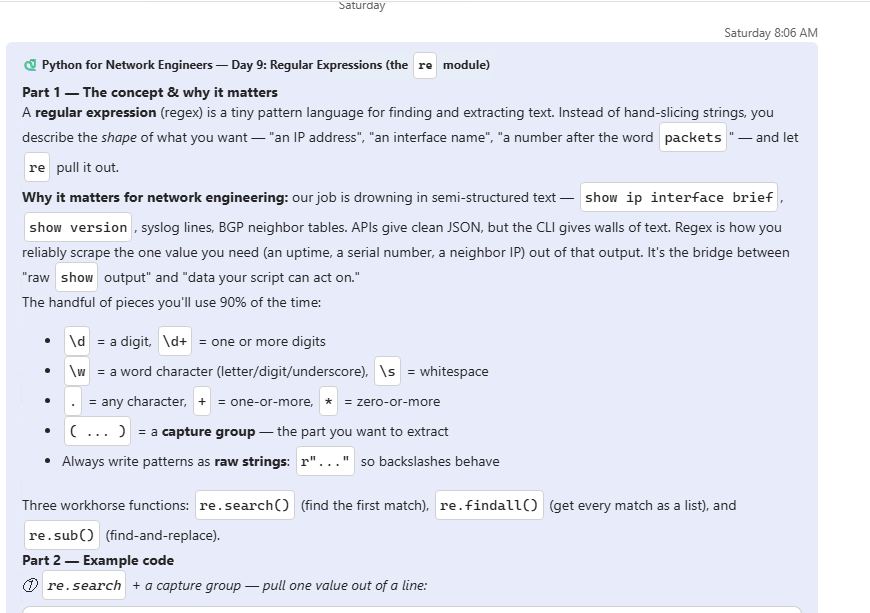



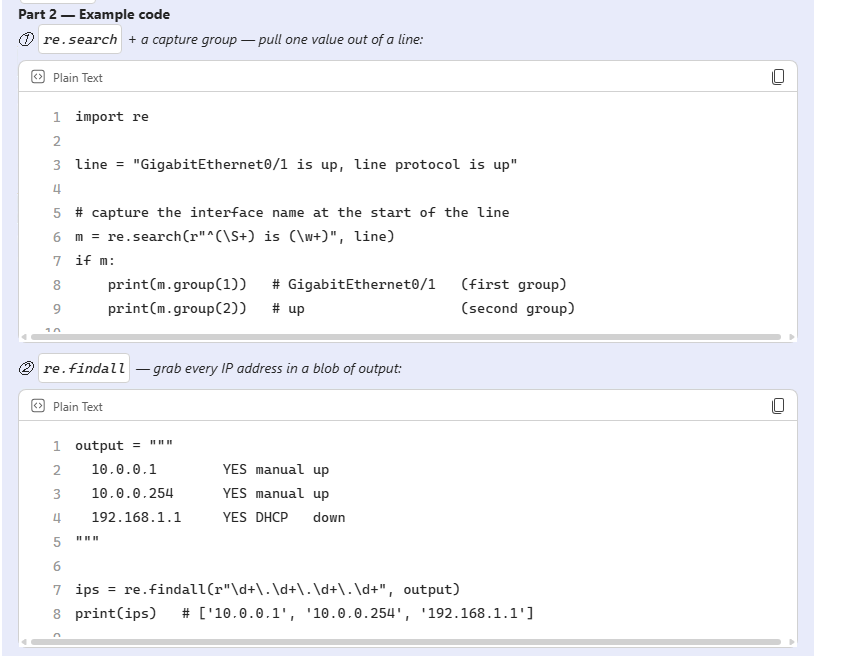


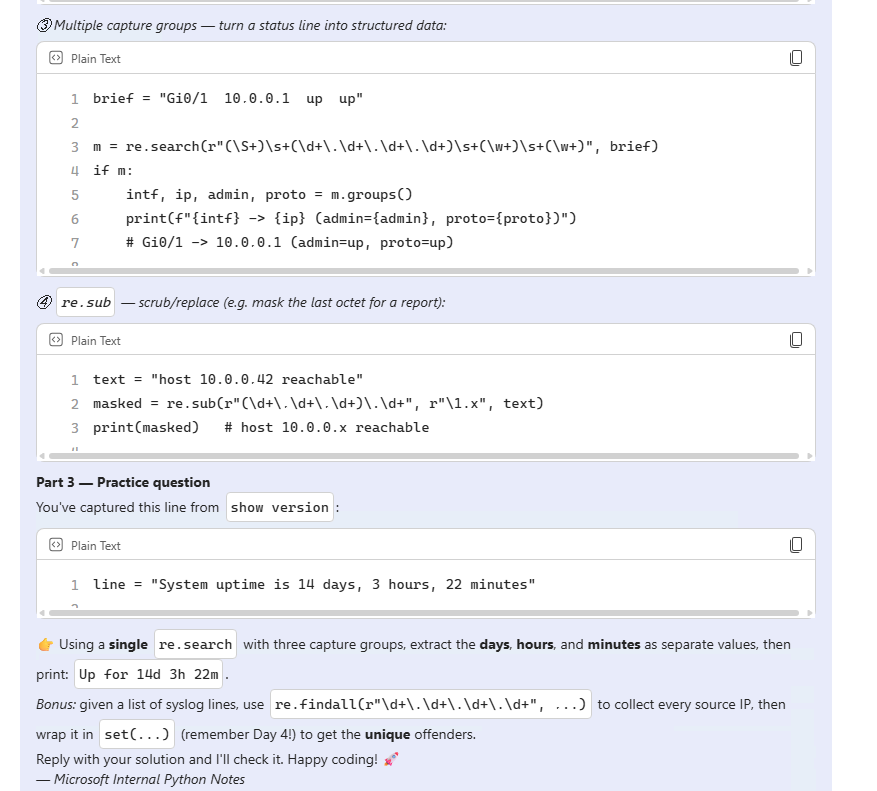



